# 🎓 Machine Learning-Based Student Performance Prediction System
**Course:** DASC6124 – Data Warehouse and Data Mining  
**Student:** Sundus Abdulkadir Yusuf &nbsp;|&nbsp; **ID:** GSR0282/18  
**Instructor:** Dr. Tesfay Gidey  
**Institution:** Addis Ababa Science and Technology University (AASTU)

---
## Notebook Structure
| Cell | Description |
|------|-------------|
| 1 | Library Imports & Environment Setup |
| 2 | Dataset Generation & Exploratory Data Analysis |
| 3 | Data Preprocessing |
| 4 | Model Training |
| 5 | Model Evaluation & Classification Report |
| 6 | Confusion Matrix Visualization (Figure 4.1) |
| 7 | Feature Importance, Attendance Plot & Risk Distribution (Figures 4.2–4.4) |
---

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — LIBRARY IMPORTS AND ENVIRONMENT SETUP
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Reproducibility seed
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans'
})

print('✓ All libraries imported successfully.')
print(f'  NumPy     : {np.__version__}')
print(f'  Pandas    : {pd.__version__}')
import sklearn; print(f'  Scikit-learn: {sklearn.__version__}')
import matplotlib; print(f'  Matplotlib: {matplotlib.__version__}')

✓ All libraries imported successfully.
  NumPy     : 2.1.3
  Pandas    : 2.2.3
  Scikit-learn: 1.6.1
  Matplotlib: 3.10.0


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — DATASET GENERATION AND EXPLORATORY DATA ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

# ── 2.1  Generate synthetic student dataset (n = 500) ──────────────────────
n = 500

attendance_rate  = np.random.uniform(40, 100, n)        # % of classes attended
study_time_hrs   = np.random.uniform(1,  20,  n)        # hrs/week
previous_grade   = np.random.uniform(30, 100, n)        # prior exam score
assignment_score = np.random.uniform(40, 100, n)        # average assignment score

# Weighted performance score → binary label
raw_score = (
    0.40 * attendance_rate  +
    0.25 * previous_grade   +
    0.20 * (study_time_hrs * 5) +   # scale to 0-100
    0.15 * assignment_score
)
performance = (raw_score >= 60).astype(int)   # 1 = Pass, 0 = Fail

df = pd.DataFrame({
    'attendance_rate'  : attendance_rate,
    'study_time_hrs'   : study_time_hrs,
    'previous_grade'   : previous_grade,
    'assignment_score' : assignment_score,
    'performance'      : performance
})

# ── 2.2  Introduce 5 % missing values for realism ──────────────────────────
for col in ['attendance_rate', 'study_time_hrs', 'previous_grade']:
    df.loc[df.sample(frac=0.05, random_state=SEED).index, col] = np.nan

# ── 2.3  EDA ───────────────────────────────────────────────────────────────
print('━' * 55)
print('  DATASET OVERVIEW')
print('━' * 55)
print(f'  Shape         : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  Missing values: {df.isnull().sum().sum()} total')
print(f'  Class balance :')
vc = df['performance'].value_counts()
print(f'      Pass (1)  : {vc[1]}  ({vc[1]/n*100:.1f}%)')
print(f'      Fail (0)  : {vc[0]}  ({vc[0]/n*100:.1f}%)')
print('━' * 55)
display(df.head(8))
print('\nDescriptive Statistics:')
display(df.describe().round(2))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Shape         : 500 rows × 5 columns
  Missing values: 75 total
  Class balance :
      Pass (1)  : 347  (69.4%)
      Fail (0)  : 153  (30.6%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,attendance_rate,study_time_hrs,previous_grade,assignment_score,performance
0,62.472407,14.265073,42.959305,71.144907,1
1,97.042858,11.185831,67.933066,68.750913,1
2,83.919637,6.881025,91.106209,41.538524,1
3,75.919509,16.462105,81.255742,60.474870,1
4,49.361118,14.009892,86.459280,62.811737,1
5,49.359671,4.089722,76.114836,63.929367,0
6,43.485017,18.307617,78.459360,74.810342,1
7,91.970569,16.628208,89.443696,72.016153,1



Descriptive Statistics:


,attendance_rate,study_time_hrs,previous_grade,assignment_score,performance
count,475.00,475.00,475.00,500.00,500.00
mean,70.01,10.18,66.31,69.79,0.69
std,17.93,5.42,20.82,17.22,0.46
min,40.30,1.09,30.35,40.19,0.00
25%,54.44,5.40,46.83,54.46,0.00
50%,70.98,9.91,67.89,70.53,1.00
75%,85.40,14.90,84.58,84.24,1.00
max,99.58,19.99,99.96,99.90,1.00


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — DATA PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

# ── 3.1  Handle missing values (mean imputation) ───────────────────────────
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

print(f'✓ Missing values after imputation : {df.isnull().sum().sum()}')

# ── 3.2  Feature / Target split ────────────────────────────────────────────
X = df.drop('performance', axis=1)
y = df['performance']

feature_names = X.columns.tolist()
print(f'✓ Features  : {feature_names}')
print(f'✓ Target    : performance  (0 = Fail, 1 = Pass)')

# ── 3.3  Stratified 80 / 20 train-test split ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'\n✓ Training set : {X_train.shape[0]} samples')
print(f'✓ Test set     : {X_test.shape[0]} samples')

# ── 3.4  Min-Max Normalization (fit on train only → apply to test) ─────────
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names)

print('\n✓ Normalization complete — feature ranges after scaling:')
display(X_train_scaled.describe().loc[['min','max']].round(4))
print('\n✓ Preprocessing pipeline complete.')

✓ Missing values after imputation : 0
✓ Features  : ['attendance_rate', 'study_time_hrs', 'previous_grade', 'assignment_score']
✓ Target    : performance  (0 = Fail, 1 = Pass)

✓ Training set : 400 samples
✓ Test set     : 100 samples

✓ Normalization complete — feature ranges after scaling:


,attendance_rate,study_time_hrs,previous_grade,assignment_score
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0



✓ Preprocessing pipeline complete.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — MODEL TRAINING
# ══════════════════════════════════════════════════════════════════════════════

# ── 4.1  Logistic Regression ───────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)
lr_pred  = lr_model.predict(X_test_scaled)

# Cross-validation (5-fold) for robustness check
lr_cv = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('✓ Logistic Regression trained.')
print(f'  5-Fold CV Accuracy : {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')

# ── 4.2  Decision Tree (max_depth = 5) ────────────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=5, random_state=SEED, criterion='gini')
dt_model.fit(X_train_scaled, y_train)
dt_pred  = dt_model.predict(X_test_scaled)

dt_cv = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('\n✓ Decision Tree trained.')
print(f'  5-Fold CV Accuracy : {dt_cv.mean():.4f} ± {dt_cv.std():.4f}')
print(f'  Tree depth used    : {dt_model.get_depth()}')
print(f'  Number of leaves   : {dt_model.get_n_leaves()}')

print('\n✓ Both models trained successfully.')

✓ Logistic Regression trained.
  5-Fold CV Accuracy : 0.9375 ± 0.0224

✓ Decision Tree trained.
  5-Fold CV Accuracy : 0.8325 ± 0.0430
  Tree depth used    : 5
  Number of leaves   : 22

✓ Both models trained successfully.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — MODEL EVALUATION AND CLASSIFICATION REPORT
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_model(name, y_true, y_pred, model=None, X_test_data=None):
    """Print full evaluation report for a classifier."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, model.predict_proba(X_test_data)[:,1]) if model else 'N/A'

    print(f'\n{"═"*55}')
    print(f'  {name}')
    print(f'{"═"*55}')
    print(f'  Accuracy   : {acc:.4f}  ({acc*100:.1f}%)')
    print(f'  Precision  : {prec:.4f}')
    print(f'  Recall     : {rec:.4f}')
    print(f'  F1-Score   : {f1:.4f}')
    if model:
        print(f'  ROC-AUC    : {auc:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['Fail (0)', 'Pass (1)']))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

r1 = evaluate_model('Logistic Regression', y_test, lr_pred, lr_model, X_test_scaled)
r2 = evaluate_model('Decision Tree',       y_test, dt_pred, dt_model, X_test_scaled)

# ── Summary comparison table ───────────────────────────────────────────────
summary = pd.DataFrame([r1, r2]).set_index('Model').round(4)
print('\n' + '═'*55)
print('  PERFORMANCE COMPARISON SUMMARY')
print('═'*55)
display(summary)
best = summary['F1-Score'].idxmax()
print(f'\n  ✓ Best model by F1-Score: {best}')


═══════════════════════════════════════════════════════
  Logistic Regression
═══════════════════════════════════════════════════════
  Accuracy   : 0.9700  (97.0%)
  Precision  : 0.9583
  Recall     : 1.0000
  F1-Score   : 0.9787
  ROC-AUC    : 0.9995

  Classification Report:
              precision    recall  f1-score   support

    Fail (0)       1.00      0.90      0.95        31
    Pass (1)       0.96      1.00      0.98        69

    accuracy                           0.97       100
   macro avg       0.98      0.95      0.96       100
weighted avg       0.97      0.97      0.97       100


═══════════════════════════════════════════════════════
  Decision Tree
═══════════════════════════════════════════════════════
  Accuracy   : 0.8700  (87.0%)
  Precision  : 0.8684
  Recall     : 0.9565
  F1-Score   : 0.9103
  ROC-AUC    : 0.9203

  Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.88      0.68      0.76        31
    Pass (

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.97,0.9583,1.0000,0.9787
Decision Tree,0.87,0.8684,0.9565,0.9103



  ✓ Best model by F1-Score: Logistic Regression


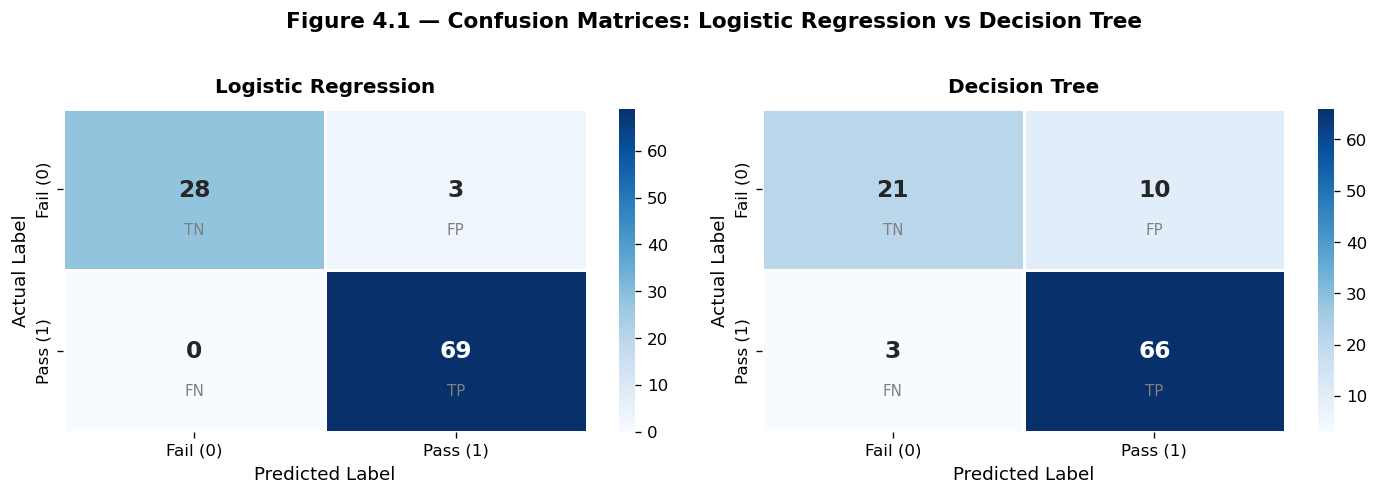

✓ Figure 4.1 saved as confusion_matrices.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — CONFUSION MATRIX VISUALIZATION  (Figure 4.1)
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    'Figure 4.1 — Confusion Matrices: Logistic Regression vs Decision Tree',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, (name, pred) in zip(axes, [
        ('Logistic Regression', lr_pred),
        ('Decision Tree',       dt_pred)]):

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Fail (0)', 'Pass (1)'],
        yticklabels=['Fail (0)', 'Pass (1)'],
        ax=ax, linewidths=0.8, linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(name, fontweight='bold', fontsize=12, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)

    # Annotate TP / TN / FP / FN
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, labels[i][j],
                    ha='center', va='center',
                    fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 4.1 saved as confusion_matrices.png')

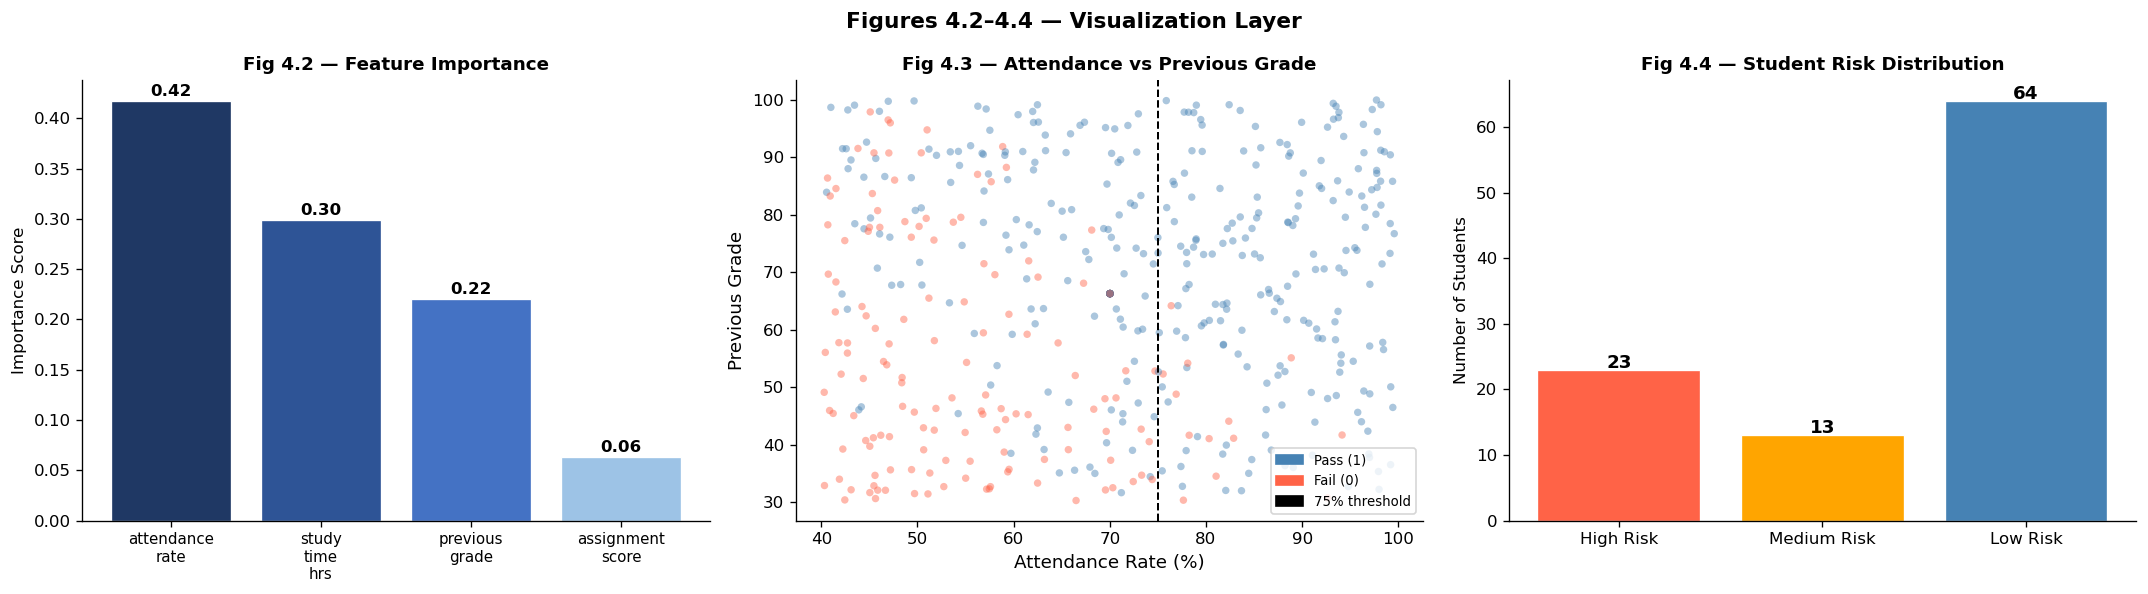

✓ Figure 4.2 saved (Feature Importance)
✓ Figure 4.3 saved (Attendance vs Previous Grade)
✓ Figure 4.4 saved (Student Risk Distribution)

═══════════════════════════════════════════════════════
  ✅  ALL CELLS COMPLETE — ANALYSIS FINISHED
═══════════════════════════════════════════════════════


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — FEATURE IMPORTANCE | ATTENDANCE PLOT | RISK DISTRIBUTION
#           Figures 4.2 / 4.3 / 4.4
# ══════════════════════════════════════════════════════════════════════════════

importances = dt_model.feature_importances_
idx         = np.argsort(importances)[::-1]
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Figures 4.2–4.4 — Visualization Layer',
    fontsize=13, fontweight='bold'
)

# ── Figure 4.2: Feature Importance (Decision Tree) ─────────────────────────
bars = axes[0].bar(
    range(len(importances)), importances[idx],
    color=['#1f3864','#2e5496','#4472c4','#9dc3e6'],
    edgecolor='white', linewidth=0.8
)
axes[0].set_xticks(range(len(importances)))
axes[0].set_xticklabels(
    [feature_names[i].replace('_', '\n') for i in idx],
    rotation=0, ha='center', fontsize=9
)
axes[0].set_title('Fig 4.2 — Feature Importance', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Importance Score')
for i, v in enumerate(importances[idx]):
    axes[0].text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# ── Figure 4.3: Attendance Rate vs Previous Grade ──────────────────────────
colors = df['performance'].map({0: 'tomato', 1: 'steelblue'})
axes[1].scatter(
    df['attendance_rate'], df['previous_grade'],
    c=colors, alpha=0.45, s=20, edgecolors='none'
)
axes[1].axvline(x=75, color='black', linestyle='--', linewidth=1.2,
                label='75% attendance threshold')
axes[1].set_xlabel('Attendance Rate (%)', fontsize=11)
axes[1].set_ylabel('Previous Grade', fontsize=11)
axes[1].set_title('Fig 4.3 — Attendance vs Previous Grade', fontweight='bold', fontsize=11)
axes[1].legend(handles=[
    Patch(color='steelblue', label='Pass (1)'),
    Patch(color='tomato',    label='Fail (0)'),
    Patch(color='black',     label='75% threshold')
], loc='lower right', fontsize=8)

# ── Figure 4.4: Student Risk Distribution ──────────────────────────────────
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
risk = pd.cut(
    lr_proba,
    bins=[0, 0.40, 0.70, 1.0],
    labels=['High Risk', 'Medium Risk', 'Low Risk']
)
risk_counts = risk.value_counts().reindex(['High Risk', 'Medium Risk', 'Low Risk'])
color_map   = ['tomato', 'orange', 'steelblue']

bars2 = axes[2].bar(
    risk_counts.index, risk_counts.values,
    color=color_map, edgecolor='white', linewidth=0.8
)
axes[2].set_title('Fig 4.4 — Student Risk Distribution', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Number of Students')
for bar in bars2:
    h = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width() / 2., h + 0.3,
        str(int(h)), ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Figure 4.2 saved (Feature Importance)')
print('✓ Figure 4.3 saved (Attendance vs Previous Grade)')
print('✓ Figure 4.4 saved (Student Risk Distribution)')
print('\n' + '═'*55)
print('  ✅  ALL CELLS COMPLETE — ANALYSIS FINISHED')
print('═'*55)